In [1]:
import json
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')
import datetime as dt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
with open("ultimate_data_challenge.json", 'r') as f:
    data = json.load(f)

In [3]:
df = pd.DataFrame(data)

In [4]:
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])

In [5]:
df.isnull().sum()

city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                      396
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
dtype: int64

In [6]:
df.isnull().mean() * 100

city                       0.000
trips_in_first_30_days     0.000
signup_date                0.000
avg_rating_of_driver      16.244
avg_surge                  0.000
last_trip_date             0.000
phone                      0.792
surge_pct                  0.000
ultimate_black_user        0.000
weekday_pct                0.000
avg_dist                   0.000
avg_rating_by_driver       0.402
dtype: float64

In [7]:
present = df.sort_values('last_trip_date').tail(1)['last_trip_date'].values[0]
month_previous = present - np.timedelta64(30, 'D')
df['active'] = df['last_trip_date'] >= month_previous

In [8]:
percent_retained = np.sum(df['active']) / len(df)
print(f"Overall retention rate: {percent_retained:.2%}")

Overall retention rate: 37.61%


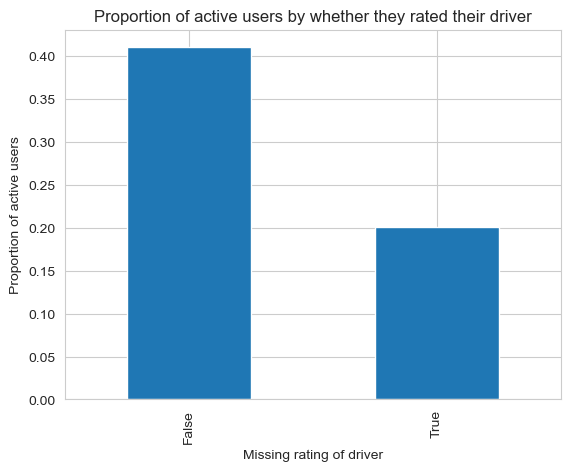

In [9]:
df['missing_rating_of_driver'] = df['avg_rating_of_driver'].isnull()
df_active_by_missing_rating_of_driver = df.groupby('missing_rating_of_driver')['active'].apply(lambda x: np.sum(x) / len(x))
df_active_by_missing_rating_of_driver.plot(kind='bar')
plt.title('Proportion of active users by whether they rated their driver')
plt.xlabel('Missing rating of driver')
plt.ylabel('Proportion of active users')
plt.show()

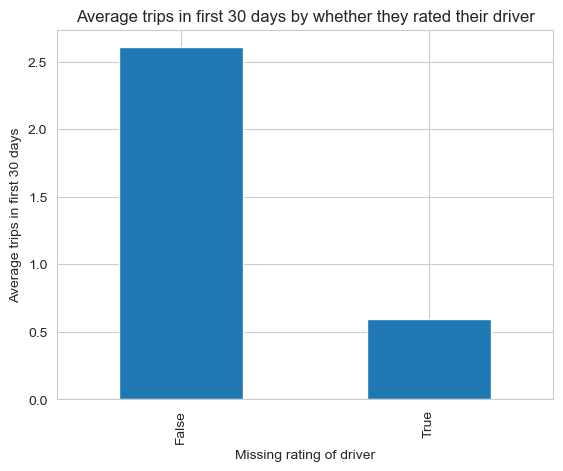

In [10]:
df['trips_in_first_30_days'].groupby(df['missing_rating_of_driver']).mean().plot(kind='bar')
plt.title('Average trips in first 30 days by whether they rated their driver')
plt.xlabel('Missing rating of driver')
plt.ylabel('Average trips in first 30 days')
plt.show()

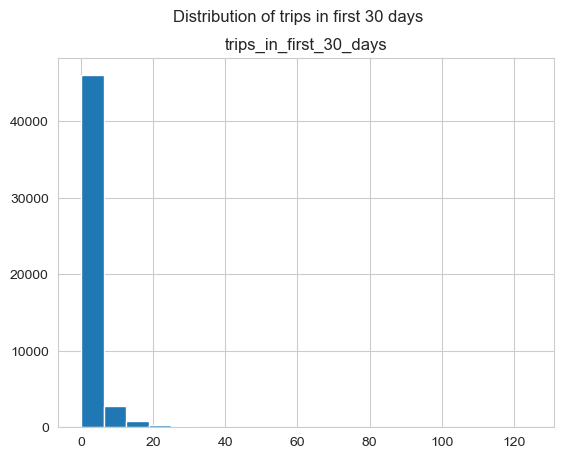

In [11]:
df.hist(column='trips_in_first_30_days', bins=20)
plt.suptitle('Distribution of trips in first 30 days')
plt.show()

In [12]:
df['trips_in_first_30_days'].describe()

count    50000.000000
mean         2.278200
std          3.792684
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max        125.000000
Name: trips_in_first_30_days, dtype: float64

In [13]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

mask = pd.Series(True, index=df.index)
for col in numeric_cols:
    mask &= df[col].between(lower_bound[col], upper_bound[col]) | df[col].isna()

df_no_outliers = df[mask].copy()
print(f"Rows before: {len(df)}, after removing outliers: {len(df_no_outliers)}")

Rows before: 50000, after removing outliers: 30112


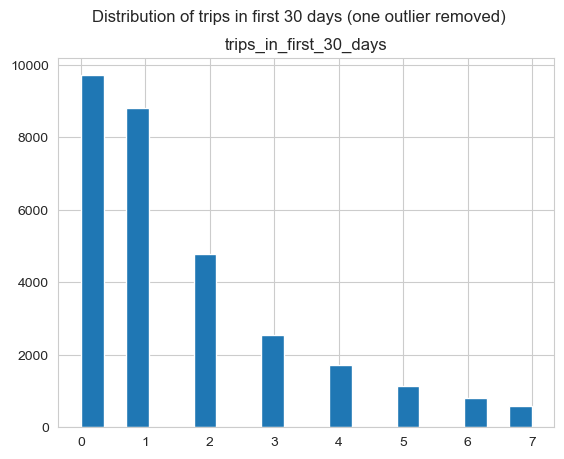

In [14]:
df_no_outliers.hist(column='trips_in_first_30_days', bins=20)
plt.suptitle('Distribution of trips in first 30 days (one outlier removed)')
plt.show()

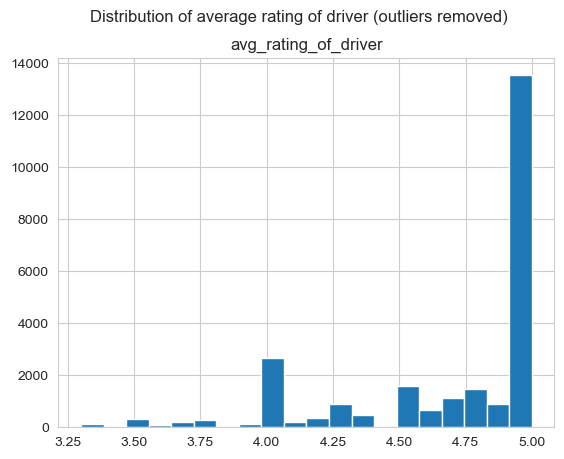

In [15]:
df_no_outliers.hist(column='avg_rating_of_driver', bins=20)
plt.suptitle('Distribution of average rating of driver (outliers removed)')
plt.show()

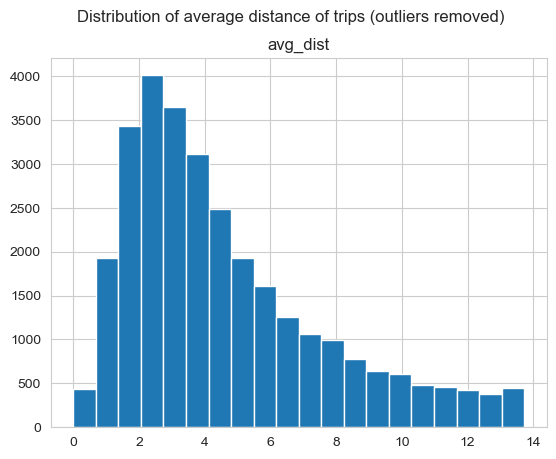

In [16]:
df_no_outliers.hist(column='avg_dist', bins=20)
plt.suptitle('Distribution of average distance of trips (outliers removed)')
plt.show()

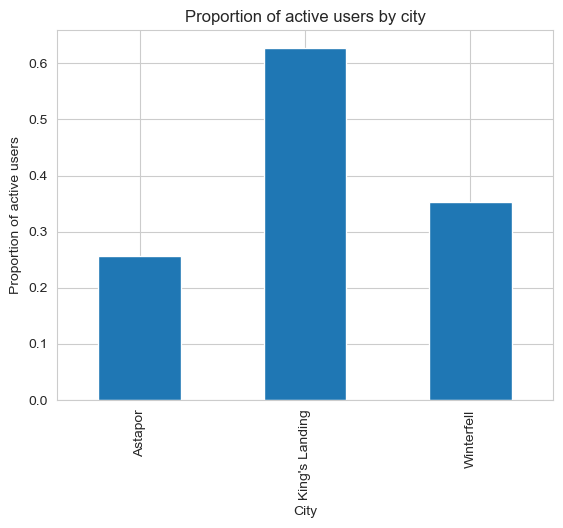

In [17]:
df_active_by_city = df.groupby('city')['active'].apply(lambda x: np.sum(x) / len(x))
df_active_by_city.plot(kind='bar')
plt.title('Proportion of active users by city')
plt.xlabel('City')
plt.ylabel('Proportion of active users')
plt.show()

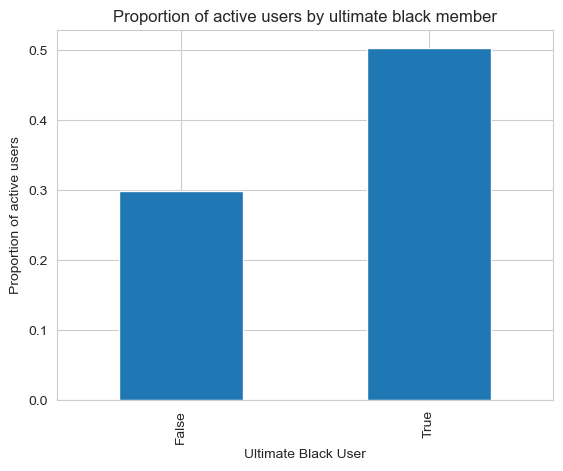

In [18]:
df_active_by_ultimate_black_user = df.groupby('ultimate_black_user')['active'].apply(lambda x: np.sum(x) / len(x))
df_active_by_ultimate_black_user.plot(kind='bar')
plt.title('Proportion of active users by ultimate black member')
plt.xlabel('Ultimate Black User')
plt.ylabel('Proportion of active users')
plt.show()

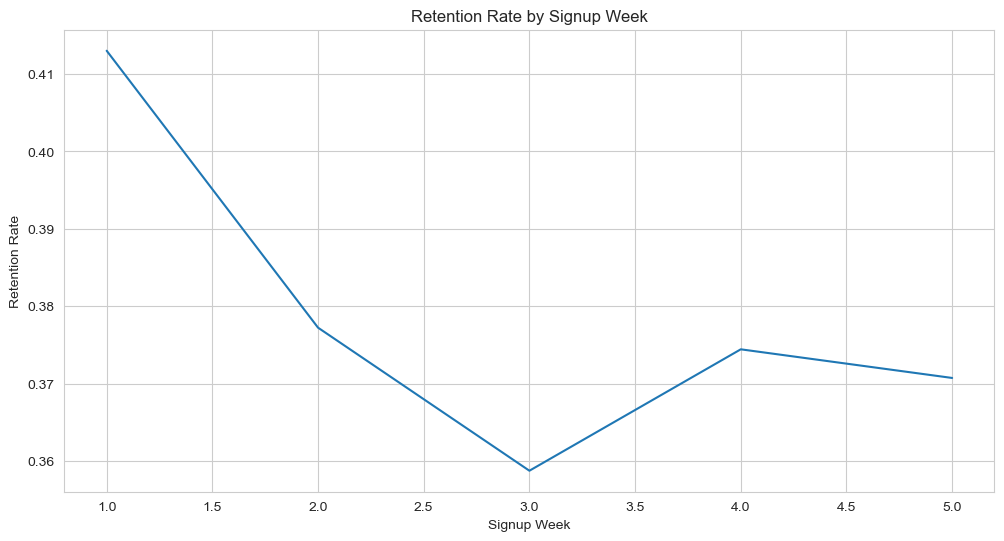

In [19]:
df['signup_week'] = df['signup_date'].dt.isocalendar().week
retention_by_week = df.groupby('signup_week')['active'].apply(lambda x: np.sum(x) / len(x))
retention_by_week.plot(kind='line', figsize=(12, 6))
plt.title('Retention Rate by Signup Week')
plt.xlabel('Signup Week')
plt.ylabel('Retention Rate')
plt.show()

C:\Users\Adam\AppData\Local\Temp\ipykernel_17748\1159371848.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  retention_by_bucket = df.groupby(trip_buckets)['active'].mean()


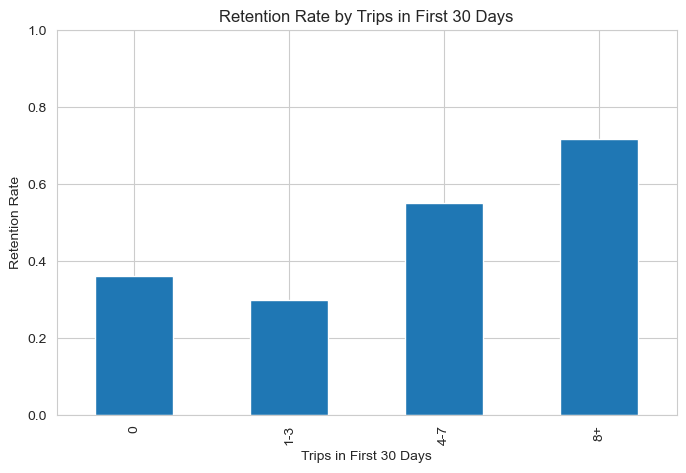

In [20]:
trip_buckets = pd.cut(
    df['trips_in_first_30_days'],
    bins=[-1, 0, 3, 7, df['trips_in_first_30_days'].max()],
    labels=['0', '1-3', '4-7', '8+']
)

retention_by_bucket = df.groupby(trip_buckets)['active'].mean()

retention_by_bucket.plot(kind='bar', figsize=(8, 5))
plt.title('Retention Rate by Trips in First 30 Days')
plt.xlabel('Trips in First 30 Days')
plt.ylabel('Retention Rate')
plt.ylim(0, 1)
plt.show()

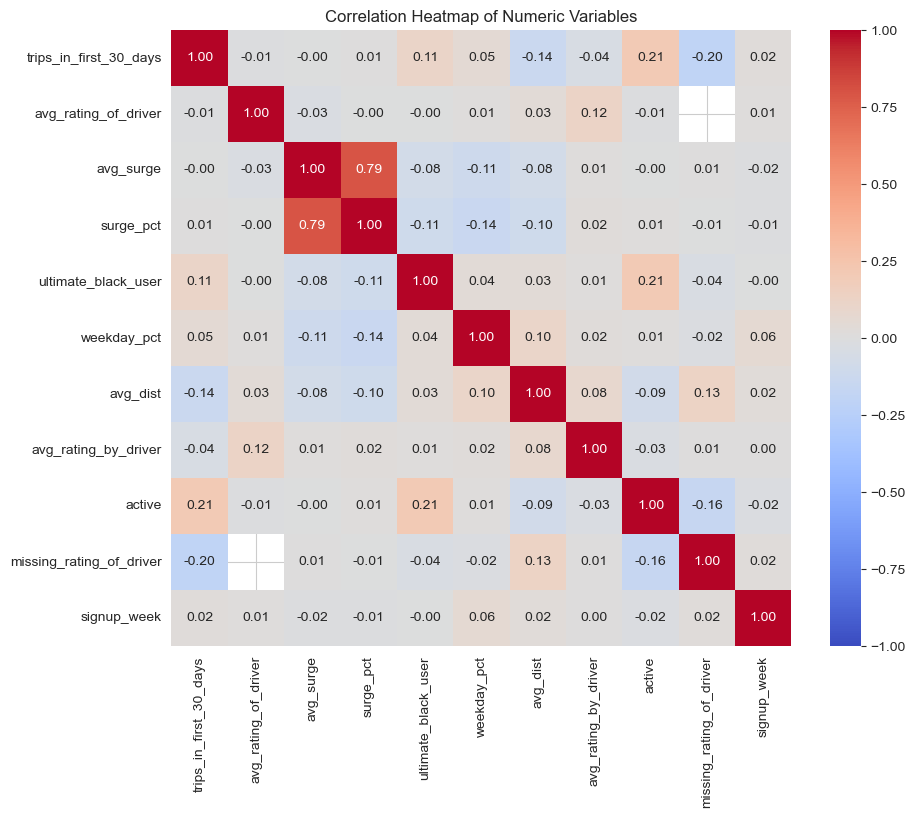

In [21]:
numeric_df = df.select_dtypes(include=['number','bool'])
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

# EDA Summary
- Rating of driver data is missing at a rate of 16.2%
- Customers who rated their driver are about twice as likely to be retained than those who didn't
- Riders who took few rides in the first 30 days after signup were less likely to rate their drivers
- The overall customer retention rate is 37.6%
- Most users only took a handful of trips (<7) in the first 30 days
- Customers in King's landing apparently are retained at a higher rate than the other two cities
- Ultimate Black users are more likely to remain active users
- Retention rate is higher for early signups and higher early trip volume
-  Customer retention is most strongly correlated to early trip volume and whether they are a premium user

# Modeling

In [22]:
df['active'] = df['active'].astype(int)
df['ultimate_black_user'] = df['ultimate_black_user'].astype(int)
df['missing_rating_of_driver'] = df['missing_rating_of_driver'].astype(int)
df['customer_lifetime'] = (df['last_trip_date'] - df['signup_date']).dt.days

In [23]:
#Remove leaking features and dates
df_model = df.drop(columns=['last_trip_date', 'customer_lifetime','signup_date'])

In [24]:
X = df_model.drop(columns=['active'])
y = df_model['active']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [25]:
X.dtypes

city                         object
trips_in_first_30_days        int64
avg_rating_of_driver        float64
avg_surge                   float64
phone                        object
surge_pct                   float64
ultimate_black_user           int64
weekday_pct                 float64
avg_dist                    float64
avg_rating_by_driver        float64
missing_rating_of_driver      int64
signup_week                  UInt32
dtype: object

In [26]:
numeric_features = [
    'avg_dist', 'avg_surge', 'surge_pct',
    'trips_in_first_30_days', 'weekday_pct',
    'avg_rating_by_driver', 'avg_rating_of_driver',
    'signup_week', 'missing_rating_of_driver',
    'ultimate_black_user'
]
categorical_features = ['city', 'phone']

numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Logistic Regression

In [27]:
model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [28]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("AUC:", roc_auc_score(y_test, y_pred_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

AUC: 0.765724468470517
Accuracy: 0.7263
              precision    recall  f1-score   support

           0       0.74      0.86      0.80      6239
           1       0.68      0.51      0.58      3761

    accuracy                           0.73     10000
   macro avg       0.71      0.68      0.69     10000
weighted avg       0.72      0.73      0.72     10000



[[5353  886]
 [1851 1910]]


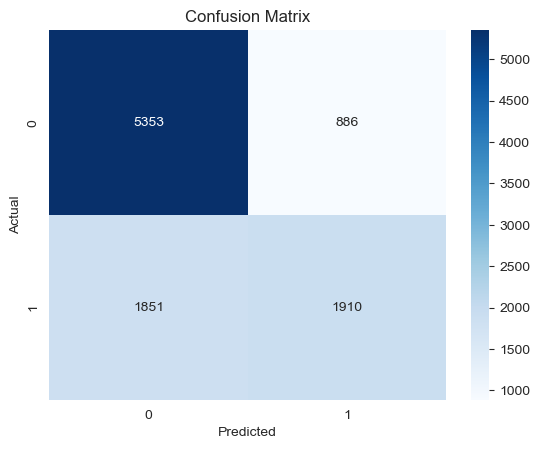

In [29]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [30]:
auc_scores = cross_val_score(
    model, X, y, cv=5, scoring='roc_auc'
)

In [31]:
print("Cross-validated AUC scores:", auc_scores)
print("Mean AUC score:", auc_scores.mean())
print("Standard Deviation of AUC scores:", auc_scores.std())

Cross-validated AUC scores: [0.76913148 0.76222451 0.76006968 0.76817539 0.77547167]
Mean AUC score: 0.7670145445392568
Standard Deviation of AUC scores: 0.005450275026744416


In [32]:
modeling_step = model.named_steps['model']
feature_names_num = numeric_features
feature_names_cat = model.named_steps['preprocess'] \
    .named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(categorical_features)

feature_names = np.concatenate([feature_names_num, feature_names_cat])
coef = modeling_step.coef_[0]

coef_table = pd.DataFrame({
    'feature': feature_names,
    'coef': coef
}).sort_values(by='coef', ascending=False)
coef_table.head(20)


,feature,coef
11,city_King's Landing,1.045324
9,ultimate_black_user,0.867485
14,phone_iPhone,0.621538
3,trips_in_first_30_days,0.103380
15,phone_None,0.020075
2,surge_pct,0.003239
4,weekday_pct,-0.000138
0,avg_dist,-0.032175
7,signup_week,-0.035551
6,avg_rating_of_driver,-0.052142


# Random Forest

In [33]:
rf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(random_state=1))
])

param_grid = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [None, 5, 10]
}

grid = GridSearchCV(
    rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1
)
grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__n_estimators': [100, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [34]:
grid.best_params_

{'model__max_depth': 10, 'model__n_estimators': 300}

In [35]:
grid.best_score_

np.float64(0.850602650013628)

In [36]:
best_model = grid.best_estimator_
y_pred_proba_rf = best_model.predict_proba(X_test)[:, 1]
y_pred_rf = best_model.predict(X_test)

In [37]:
print("AUC:", roc_auc_score(y_test, y_pred_proba_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

AUC: 0.8517290031625563
Accuracy: 0.7828
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      6239
           1       0.74      0.65      0.69      3761

    accuracy                           0.78     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.78      0.78      0.78     10000



In [38]:
rf_model = best_model.named_steps['model']
feature_importances = rf_model.feature_importances_

In [40]:
cat_encoder = best_model.named_steps['preprocess'] \
                     .named_transformers_['cat'] \
                     .named_steps['onehot']

categorical_feature_names = cat_encoder.get_feature_names_out(['city', 'phone'])


In [41]:
feature_names = np.concatenate([numeric_features, categorical_feature_names])

In [44]:
importance_table = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

importance_table.head(15)


,feature,importance
5,avg_rating_by_driver,0.191990
2,surge_pct,0.130936
11,city_King's Landing,0.117657
4,weekday_pct,0.116510
1,avg_surge,0.088494
9,ultimate_black_user,0.055960
3,trips_in_first_30_days,0.054358
0,avg_dist,0.050826
13,phone_Android,0.046426
14,phone_iPhone,0.040020


# Modeling Discussion

Two model types were explored for this binary classification problem. Logistic regression (LR) for interpretability, and Random Forest (RF) for overall predictive performance and capturing of nonlinear relationships. To ensure the model reflects information Ultimate would realistically have at the time of prediction, I restricted features to those available within the first 30 days after signup. I removed last_trip_date and any derived features to avoid data leakage, which initially produced artificially high (>99%) performance. Overall model performance was evaluated by the metric ROC AUC which for the test set was 0.77 for the LR model, and 0.85 for RF. This is a significant gap in performance between the two model types and suggests that retention behavior has nonlinear dependencies and/or is influenced by interactions between variables. Based on the RF model, the top 3 predictors of retention are avg_rating_by_driver, which reflects rider behavior and satisfaction; surge_pct, which implies that riders that are willing to pay surge prices retain better; and city_King's Landing, which implies that customers from this city retain better and there is a strong city-level cohort effect. Based on the model insights, Ultimate may want to monitor city-level differences between users. Since King's Landing shows higher retention, city-specific operational strategies such as special incentives for users in lagging cities may be needed. Since users who tolerate surge pricing retain better and provide more value, Ultimate may consider implementing loyalty programs/perks for taking rides during these times.
